In [1]:
import pandas as pd
import glob
import os

# --- Load baseline ---
baseline = pd.read_csv("../../results/baseline/final_source_only_100_0.csv")

# Keep only necessary columns
baseline = baseline[["source_region", "target_region", "iou"]]
baseline = baseline.rename(columns={
    "iou": "baseline_iou",
    # "bf1": "baseline_bf1"
})

avg_baseline = baseline["baseline_iou"].mean()
print("Average baseline IoU:", avg_baseline)


Average baseline IoU: 0.17904875


In [12]:
# Load all method CSVs
files = glob.glob("../../results/shape_priors/*.csv")

records = []

for f in files:
    df = pd.read_csv(f)
    method_name = os.path.basename(f).replace(".csv", "")

    merged = df.merge(
        baseline,
        on=["source_region", "target_region"],
        how="left"
    )

    merged["method"] = method_name
    merged["delta_iou"] = merged["iou"] - merged["baseline_iou"]
    # merged["delta_bf1"] = merged["bf1"] - merged["baseline_bf1"]

    records.append(merged)

freq_all = pd.concat(records, ignore_index=True)

freq_all["source_region"] = freq_all["source_region"].str.strip()
freq_all["target_region"] = freq_all["target_region"].str.strip()

# -------------------------------------------------------------------
# STEP 2 — For each method, get the best IoU per target region
# -------------------------------------------------------------------

method_scores = []

for method_name, df_m in freq_all.groupby("method"):

    # For each target region, get the maximum IoU from ANY source
    best_per_target = (
        df_m.groupby("target_region")["iou"]
            .max()        # best IoU
    )

    # Average these best-IoU values across all targets
    avg_best_iou = best_per_target.mean()

    method_scores.append({
        "method": method_name,
        "avg_best_iou": avg_best_iou
    })

method_scores = pd.DataFrame(method_scores).sort_values(
    "avg_best_iou", ascending=False
)

print(method_scores)


      method  avg_best_iou
1  lambda_10      0.339963
2   lambda_2      0.331944
0   lambda_1      0.317700
4  lambda_30      0.317500
5   lambda_5      0.317019
3  lambda_20      0.305119


In [3]:
print(freq_all["method"].unique())


['lambda_1' 'lambda_10' 'lambda_2' 'lambda_20' 'lambda_30' 'lambda_5']


In [13]:
lambda10_df = freq_all[freq_all["method"] == "lambda_10"]
# print(lambda10_df)


In [14]:
# Clean whitespace in BOTH datasets
baseline["target_region"] = baseline["target_region"].str.strip()
baseline["source_region"] = baseline["source_region"].str.strip()

freq_all["target_region"] = freq_all["target_region"].str.strip()
freq_all["source_region"] = freq_all["source_region"].str.strip()


avg_baseline = (
    baseline.groupby("target_region")["baseline_iou"]
            .mean()
            .reset_index()
            .rename(columns={"baseline_iou": "avg_baseline_iou"})
)
best_lambda10 = (
    lambda10_df.groupby("target_region")["iou"]
               .max()
               .reset_index()
               .rename(columns={"iou": "best_lambda10_iou"})
)

compare_df = avg_baseline.merge(best_lambda10, on="target_region")
print(compare_df)


                   target_region  avg_baseline_iou  best_lambda10_iou
0            Hokkaido Iburi-Tobu          0.204660             0.3222
1      Jiuzhai valley (UAV-0.2m)          0.403400             0.5958
2      Jiuzhai valley (UAV-0.5m)          0.359247             0.5159
3                         Lombok          0.079173             0.1436
4             Longxi River (SAT)          0.044260             0.3292
5             Longxi River (UAV)          0.093960             0.2778
6              Mengdong Township          0.193573             0.3732
7           Moxi town (UAV-0.2m)          0.223860             0.4227
8             Moxi town (UAV-1m)          0.120153             0.2663
9                Moxitaidi (SAT)          0.195893             0.3068
10          Moxitaidi (UAV-0.6m)          0.169660             0.4031
11            Moxitaidi (UAV-1m)          0.156540             0.3395
12  Tiburon Peninsula (Sentinel)          0.101620             0.2493
13    Tiburon Penins

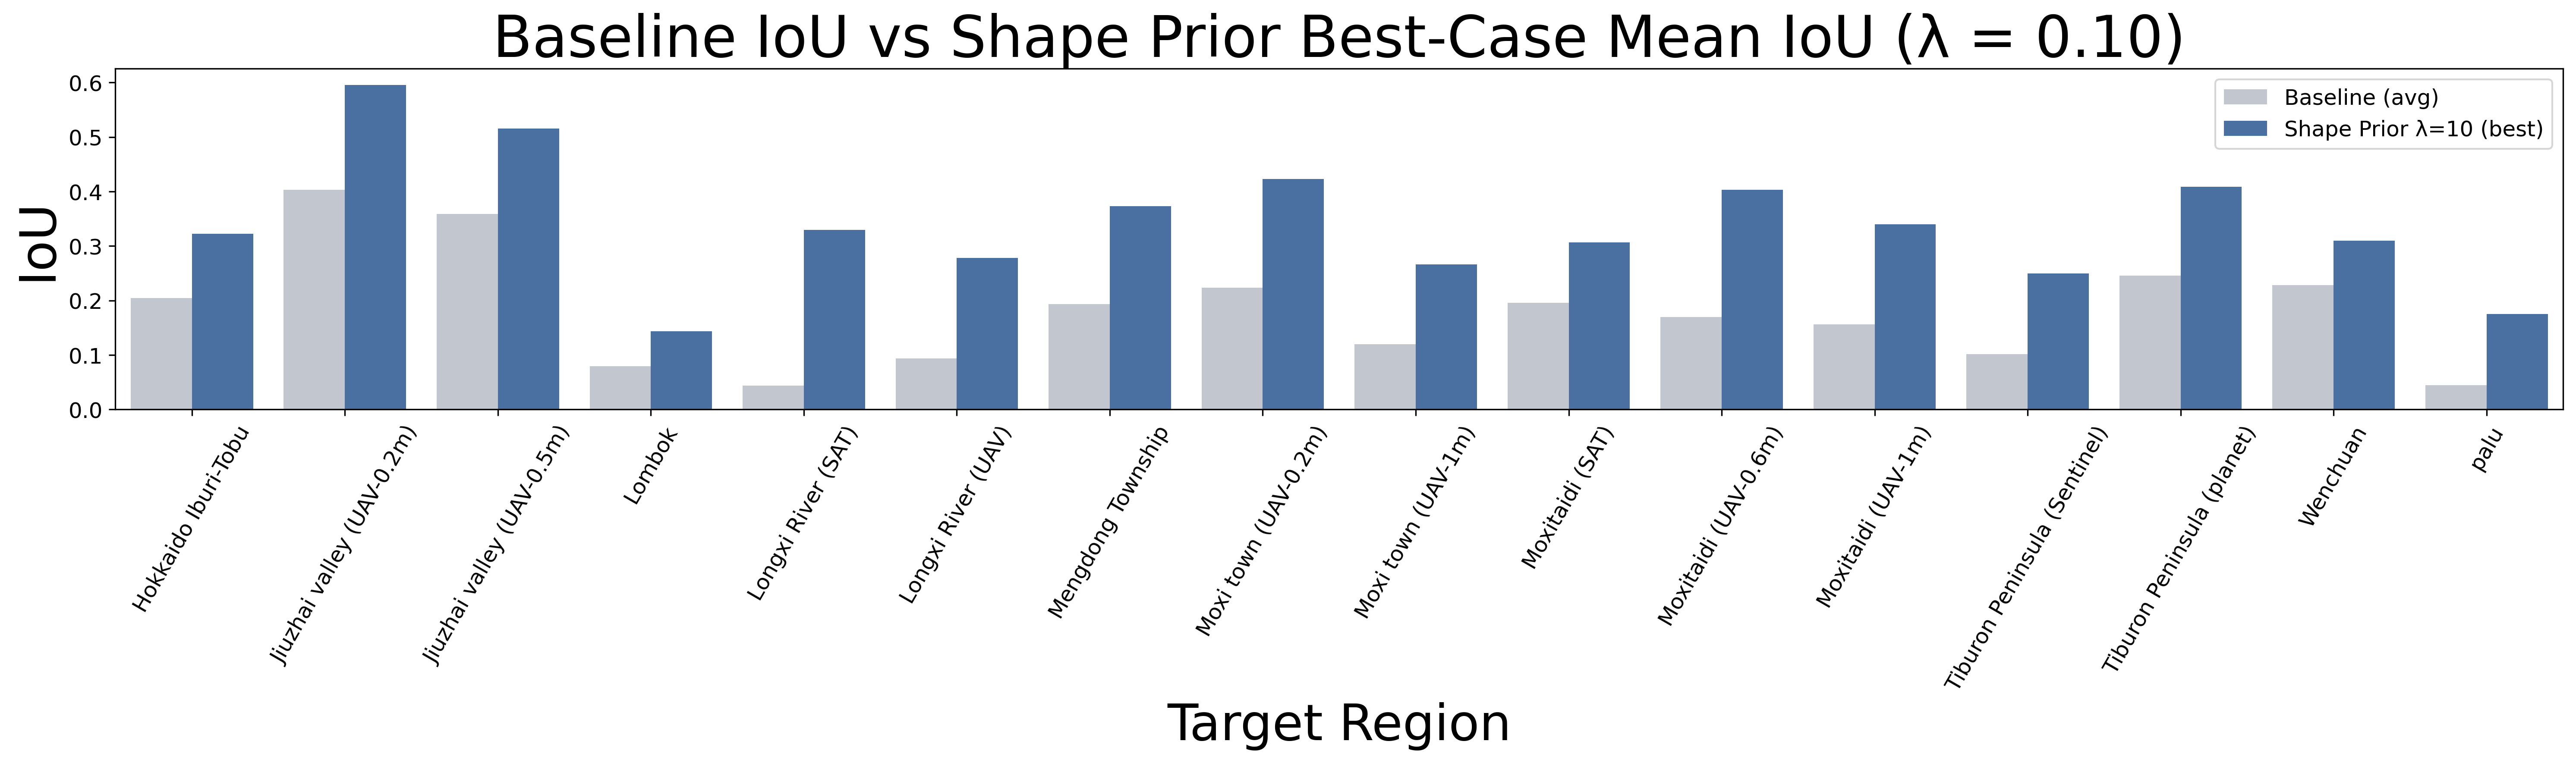

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = compare_df.melt(
    id_vars="target_region",
    value_vars=["avg_baseline_iou", "best_lambda10_iou"],
    var_name="method",
    value_name="iou"
)

plot_df["method"] = plot_df["method"].map({
    "avg_baseline_iou": "Baseline (avg)",
    "best_lambda10_iou": "Shape Prior λ=10 (best)"
})
plt.figure(figsize=(20, 6), dpi=300)

sns.barplot(
    data=plot_df,
    x="target_region",
    y="iou",
    hue="method",
    palette=["#BFC5D1", "#3C6EAF"]
)

plt.xticks(rotation=60, fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("IoU", fontsize=28)
plt.xlabel("Target Region", fontsize=28)
plt.title("Baseline IoU vs Shape Prior Best-Case Mean IoU (λ = 0.10)", fontsize=32)

plt.legend(title="", fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
compare_df = best_baseline.merge(best_lambda10, on="target_region")
print(compare_df.shape)
print(compare_df.head())


NameError: name 'best_baseline' is not defined

In [ ]:
feat = pd.read_csv("region_features.csv")
feat["region"] = feat["region"].str.strip()


In [ ]:
# Attach source-region features
df = freq_all.merge(
    feat.add_suffix("_s"),
    left_on="source_region",
    right_on="region_s",
    how="left"
)

# Attach target-region features
df = df.merge(
    feat.add_suffix("_t"),
    left_on="target_region",
    right_on="region_t",
    how="left"
)


In [ ]:
spectral_features = ["lfhf", "centroid", "entropy", "edge", "grad"]

for f in spectral_features:
    df["d_" + f] = (df[f + "_s"] - df[f + "_t"]).abs()


In [ ]:
from scipy.stats import pearsonr

def correlations_for_method(df, method_name):
    sub = df[df["method"] == method_name]

    corr_table = []
    for f in spectral_features:
        r, p = pearsonr(sub["delta_iou"], sub["d_" + f])
        corr_table.append([f, r, p])

    return pd.DataFrame(corr_table, columns=["feature", "r", "p"]).sort_values("r")


In [ ]:
corr_shape_lambda10 = correlations_for_method(df, "lambda_10")
print(corr_shape_lambda10)

    feature         r         p
4      grad -0.014818  0.819354
0      lfhf  0.001003  0.987670
2   entropy  0.048032  0.458904
1  centroid  0.077754  0.230107
3      edge  0.154508  0.016596


In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(df[df["method"] == "lambda_10"]["delta_iou"],
                df[df["method"] == "lambda_10"]["baseline_iou"])
print(r, p)

-0.2945278271451359 3.444351339830595e-06


In [ ]:
baseline_source_strength = (
    baseline.groupby("source_region")["baseline_iou"].mean()
    .rename("source_strength")
)
df = df.merge(baseline_source_strength,
              left_on="source_region",
              right_index=True,
              how="left")
r, p = pearsonr(df[df["method"] == "lambda_10"]["delta_iou"],
                df[df["method"] == "lambda_10"]["source_strength"])
print(r, p)


-0.34128721466172707 5.850790461944106e-08


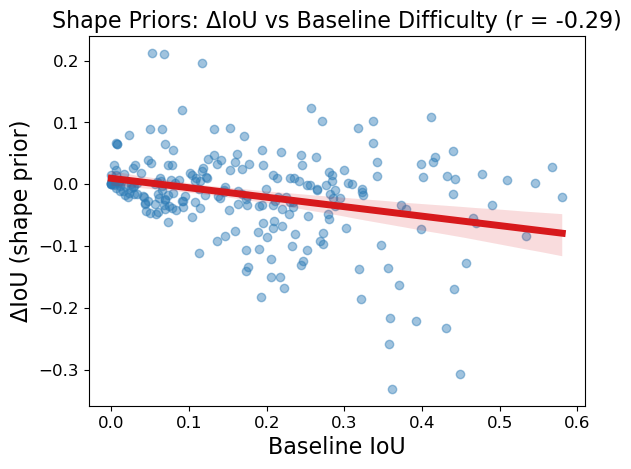

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x=df[df["method"]=="lambda_10"]["baseline_iou"],
    y=df[df["method"]=="lambda_10"]["delta_iou"],
    scatter_kws={"color":"#2C7BB6", "alpha":0.45},
    line_kws={"color":"#D7191C", "linewidth": 5}
)
plt.xlabel("Baseline IoU")
plt.ylabel("ΔIoU (shape prior)")
plt.title("Shape Priors: ΔIoU vs Baseline Difficulty (r = -0.29)", fontsize=16)
plt.show()


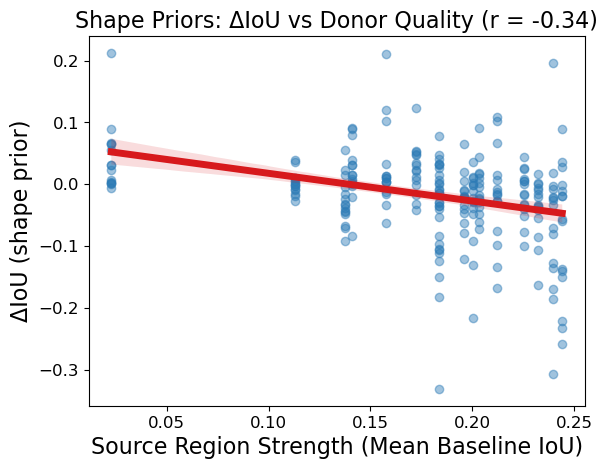

In [ ]:
sns.regplot(
    x=df[df["method"]=="lambda_10"]["source_strength"],
    y=df[df["method"]=="lambda_10"]["delta_iou"],
    scatter_kws={"color": "#2C7BB6", "alpha":0.45},
    line_kws={"color":"#D7191C", "linewidth": 5}
)
plt.xlabel("Source Region Strength (Mean Baseline IoU)")
plt.ylabel("ΔIoU (shape prior)")
plt.title("Shape Priors: ΔIoU vs Donor Quality (r = -0.34)", fontsize=16)
plt.show()


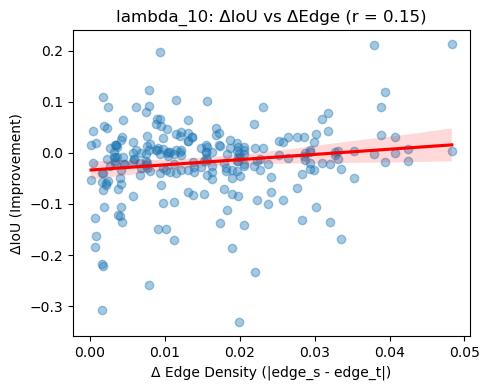

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

method = "lambda_10"
sub = df[df["method"] == method].copy()

plt.figure(figsize=(5,4))
sns.regplot(
    x=sub["d_edge"],
    y=sub["delta_iou"],
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.xlabel("Δ Edge Density (|edge_s - edge_t|)")
plt.ylabel("ΔIoU (Improvement)")
plt.title(f"{method}: ΔIoU vs ΔEdge (r = {corr_shape_lambda10.loc[corr_shape_lambda10.feature=='edge','r'].iloc[0]:.2f})")
plt.tight_layout()
plt.show()


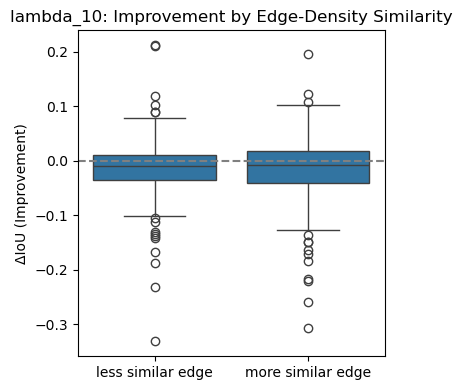

In [ ]:
import numpy as np

method = "lambda_10"
sub = df[df["method"] == method].copy()

median_edge = sub["d_edge"].median()
sub["edge_group"] = np.where(sub["d_edge"] <= median_edge,
                             "more similar edge",
                             "less similar edge")

plt.figure(figsize=(4,4))
sns.boxplot(
    data=sub,
    x="edge_group",
    y="delta_iou"
)
plt.axhline(0, linestyle="--", color="gray")
plt.ylabel("ΔIoU (Improvement)")
plt.xlabel("")
plt.title(f"{method}: Improvement by Edge-Density Similarity")
plt.tight_layout()
plt.show()


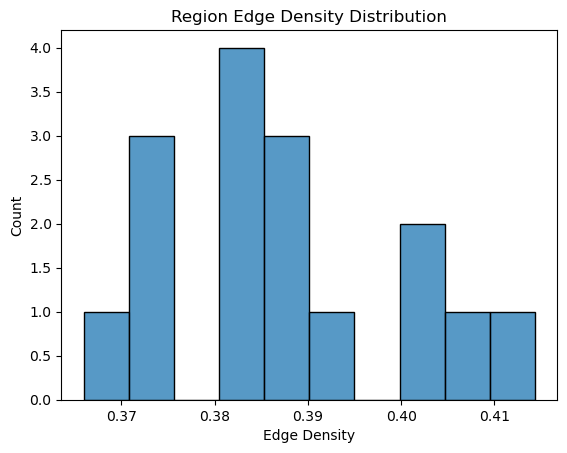

In [ ]:
sns.histplot(feat["edge"], bins=10)
plt.xlabel("Edge Density")
plt.title("Region Edge Density Distribution")
plt.show()


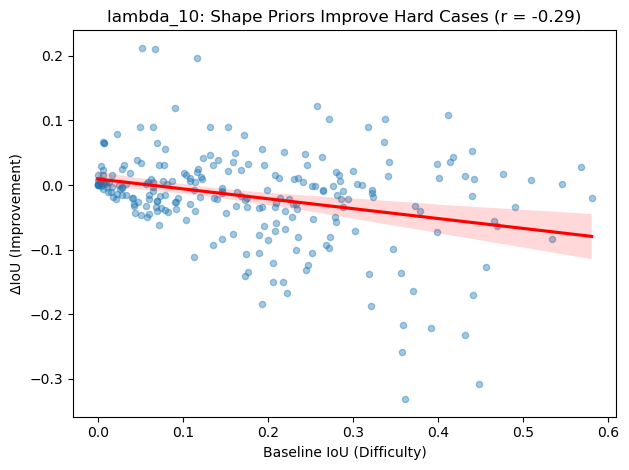

In [ ]:
method = "lambda_10"
sub = df[df["method"] == method]

sns.regplot(
    x=sub["baseline_iou"],
    y=sub["delta_iou"],
    scatter_kws={"alpha":0.4, "s":20},
    line_kws={"color":"red"}
)
plt.xlabel("Baseline IoU (Difficulty)")
plt.ylabel("ΔIoU (Improvement)")
plt.title(f"{method}: Shape Priors Improve Hard Cases (r = -0.29)")
plt.tight_layout()
plt.show()


In [ ]:


best_freq = (
    freq_all
    .sort_values(["source_region", "target_region", "delta_iou"], ascending=False)
    .groupby(["source_region", "target_region"], as_index=False)
    .first()
)

best_freq = best_freq[
    ["source_region","target_region",
     "method","iou","baseline_iou","delta_iou","bf1","baseline_bf1","delta_bf1"]
]


KeyError: "['baseline_bf1', 'delta_bf1'] not in index"

In [ ]:
winner_counts = best_freq["method"].value_counts()
print(winner_counts)


method
5_match       71
10_replace    65
10_match      56
5_replace     48
Name: count, dtype: int64


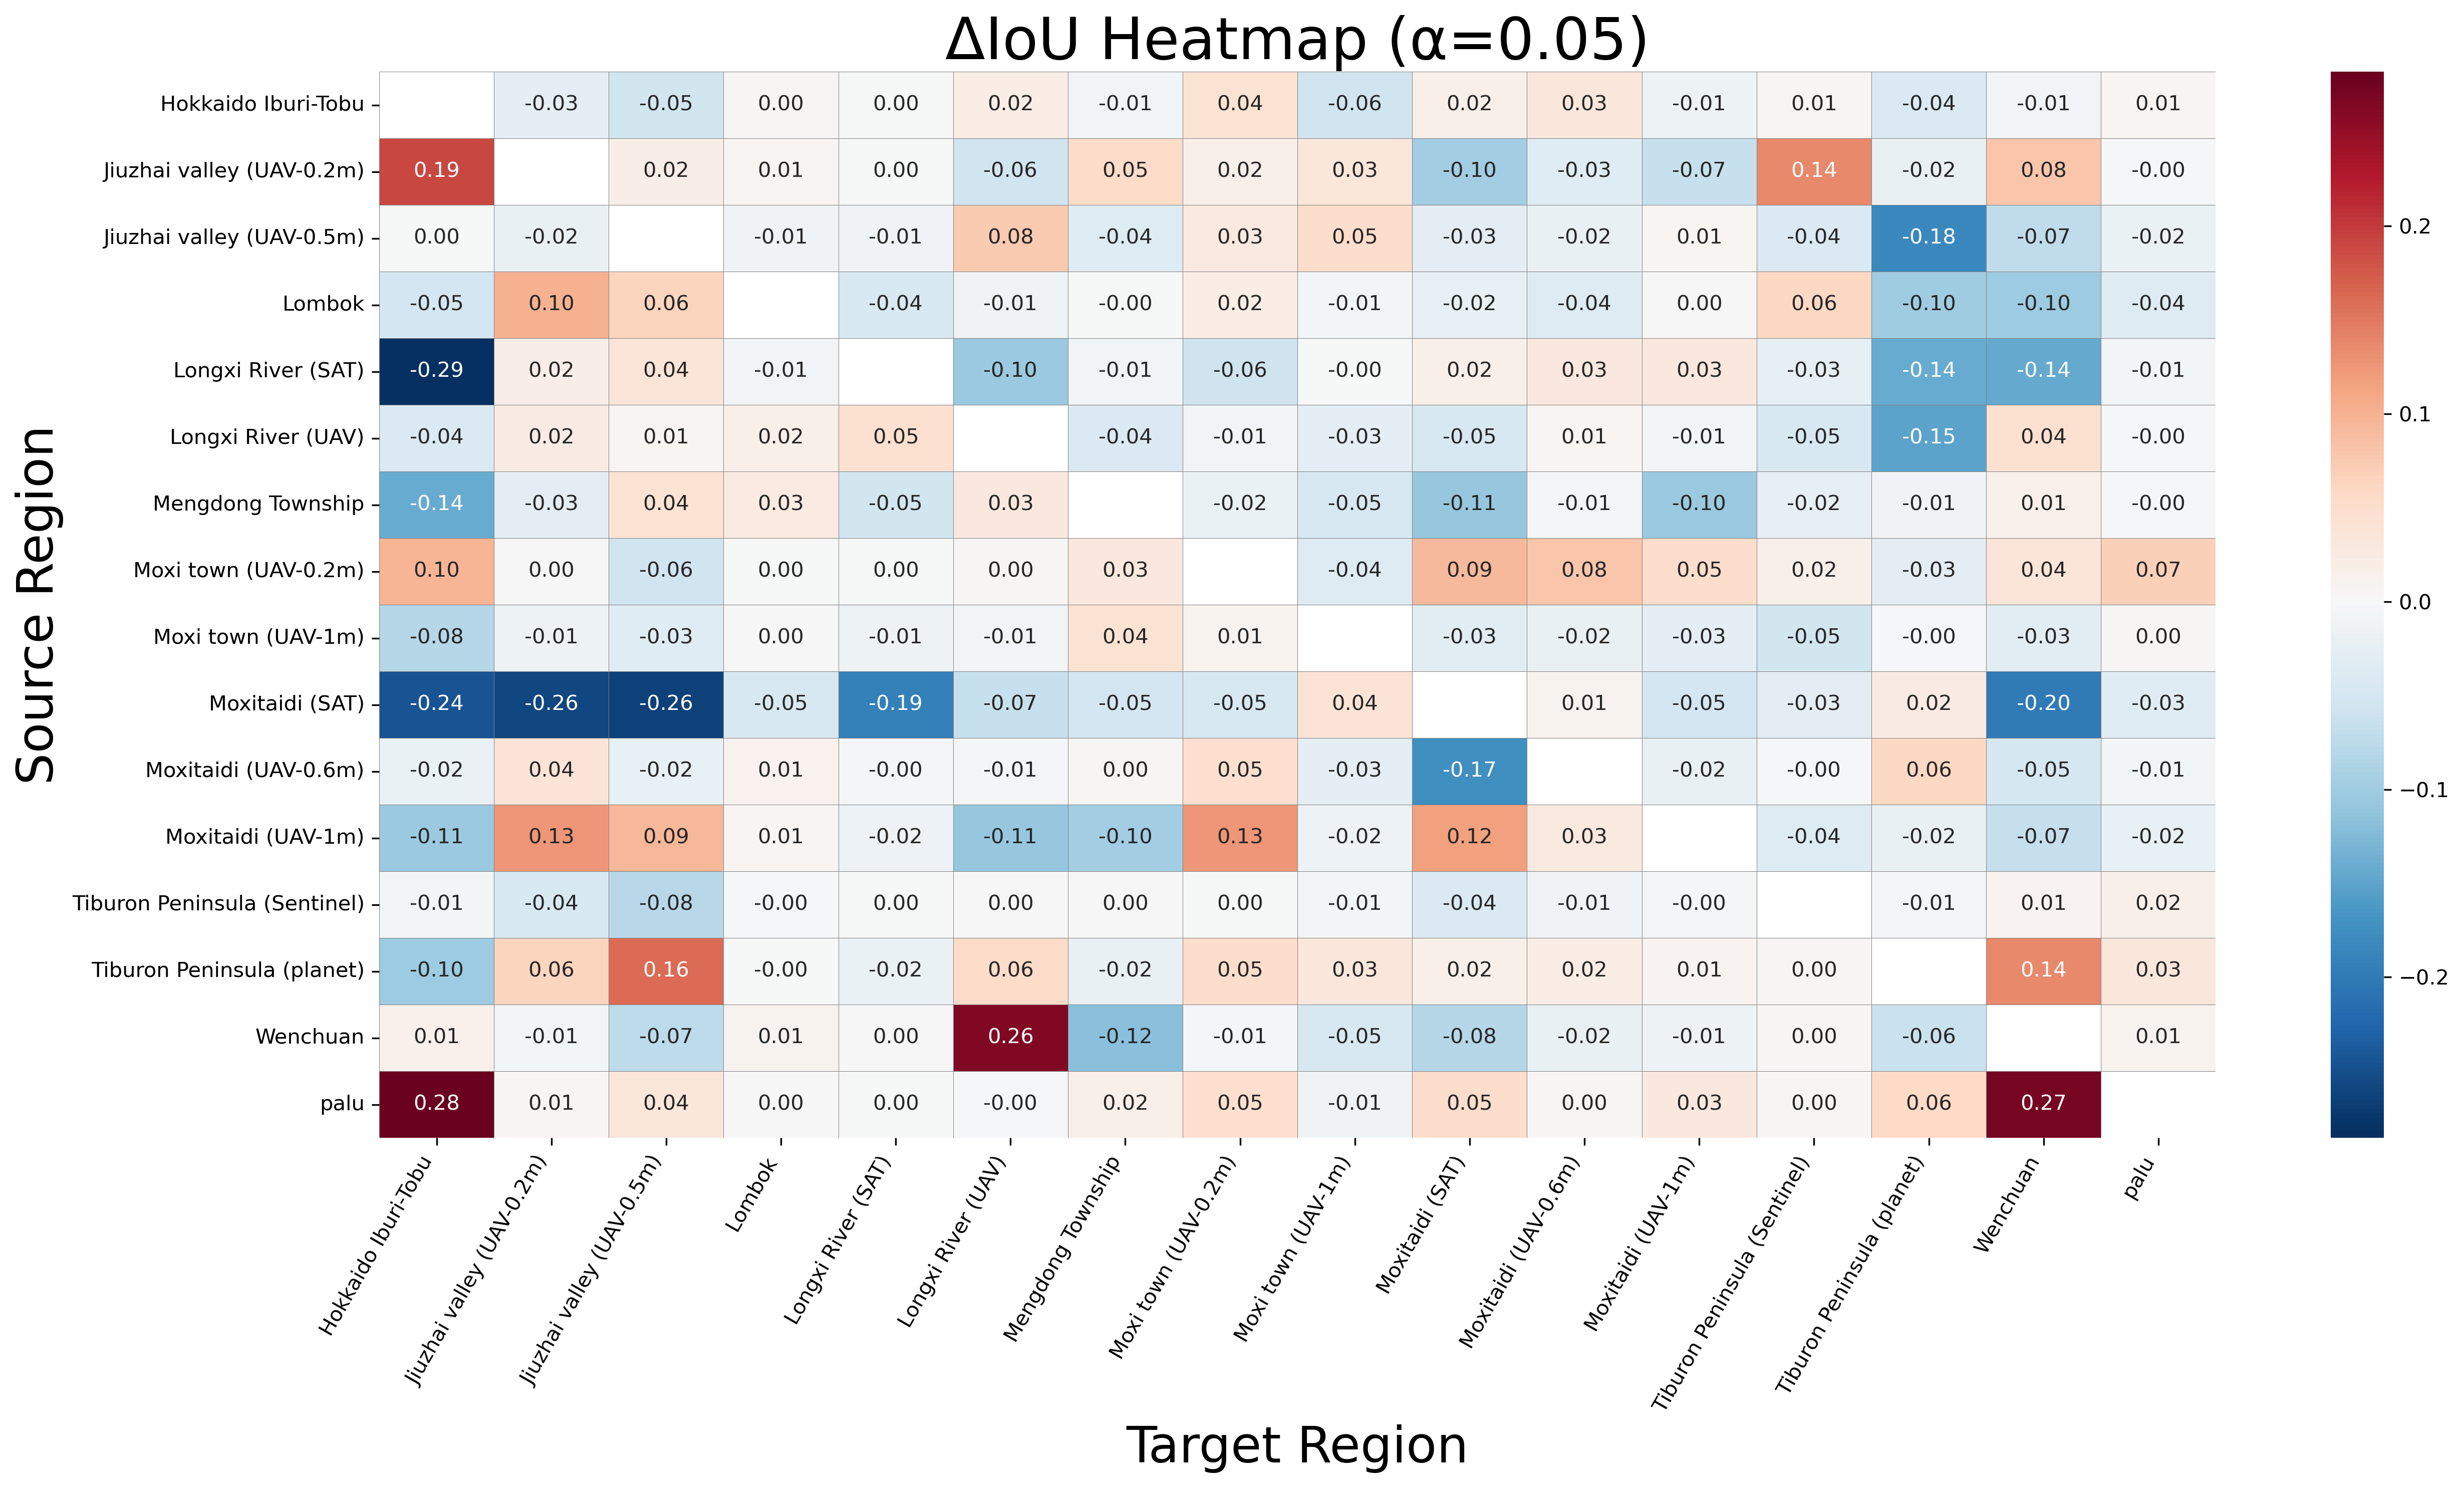

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

method = "5_replace"
df = freq_all[freq_all["method"] == method]

pivot = df.pivot(index="source_region",
                 columns="target_region",
                 values="delta_iou")

plt.figure(figsize=(18, 10), dpi=300)

sns.heatmap(
    pivot,
    cmap="RdBu_r",
    center=0,
    annot=True,             # remove later for poster version
    fmt=".02f",
    annot_kws={"size": 10},
    linewidths=0.2,
    linecolor="gray"
)

# 🔥 Bold, larger title
plt.title("ΔIoU Heatmap (α=0.05)", fontsize=28)

# 🔥 Bold, larger axis labels
plt.xlabel("Target Region", fontsize=24)
plt.ylabel("Source Region", fontsize=24)

# 🔥 Larger tick labels
plt.xticks(fontsize=10, rotation=60, ha="right")
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


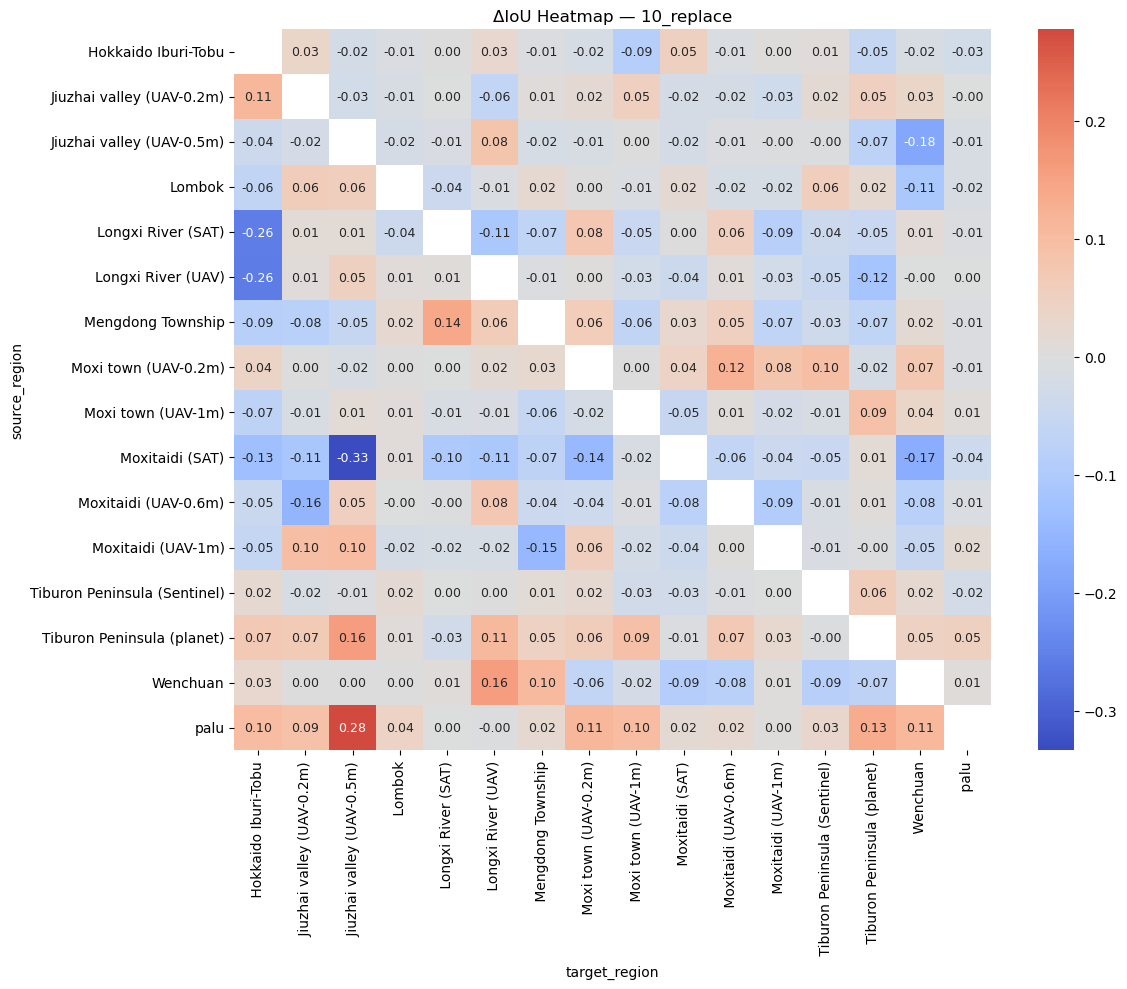

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

method = "10_replace"
df = freq_all[freq_all["method"] == method]

pivot = df.pivot(index="source_region",
                 columns="target_region",
                 values="delta_iou")

plt.figure(figsize=(12, 10))

# `annot=True` turns on numbers
# `fmt=".2f"` shows them with two decimal places
sns.heatmap(pivot,
            cmap="coolwarm",
            center=0,
            annot=True,
            fmt=".02f",
            annot_kws={"size": 9})  # adjust text size for readability

plt.title(f"ΔIoU Heatmap — {method}")
plt.xlabel("target_region")
plt.ylabel("source_region")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import glob
import os

files = glob.glob("../../results/new_wavelet/*.csv")  # path to your folder

method_avgs = []

for f in files:
    method = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(f)

    avg_iou = df["iou"].mean()
    avg_bf1 = df["bf1"].mean() if "bf1" in df.columns else None

    method_avgs.append({
        "method": method,
        "avg_iou": avg_iou,
        "avg_bf1": avg_bf1
    })

method_avgs = pd.DataFrame(method_avgs)
method_avgs = method_avgs.sort_values("avg_iou", ascending=False)

print(method_avgs)


       method   avg_iou   avg_bf1
1  10_replace  0.173918  0.119502
0    10_match  0.172648  0.118729
2     5_match  0.172455  0.117492
3   5_replace  0.170095  0.114716


wavelet!

In [ ]:
import pandas as pd
import glob, os

# --- Load baseline (same as before) ---
baseline = pd.read_csv("../../results/baseline/final_source_only_100_0.csv")
baseline = baseline[["source_region", "target_region", "iou"]].rename(
    columns={"iou": "baseline_iou"}
)

# Clean whitespace
baseline["source_region"] = baseline["source_region"].str.strip()
baseline["target_region"] = baseline["target_region"].str.strip()

# --- Load wavelet CSVs ---
files = glob.glob("../../results/old/new_fda/*.csv")  # adjust if needed

records = []
for f in files:
    df = pd.read_csv(f)

    # clean region names
    df["source_region"] = df["source_region"].str.strip()
    df["target_region"] = df["target_region"].str.strip()

    method_name = os.path.basename(f).replace(".csv", "")

    merged = df.merge(
        baseline,
        on=["source_region", "target_region"],
        how="left"
    )

    merged["method"] = method_name
    merged["delta_iou"] = merged["iou"] - merged["baseline_iou"]

    records.append(merged)

freq_wave = pd.concat(records, ignore_index=True)
print(freq_wave["method"].unique())


['01' '01_new' '05' '09']


In [ ]:
# region_features.csv from before
feat = pd.read_csv("region_features.csv")
feat["region"] = feat["region"].str.strip()

# attach source features
dfw = freq_wave.merge(
    feat.add_suffix("_s"),
    left_on="source_region",
    right_on="region_s",
    how="left"
)

# attach target features
dfw = dfw.merge(
    feat.add_suffix("_t"),
    left_on="target_region",
    right_on="region_t",
    how="left"
)

spectral_features = ["lfhf", "centroid", "entropy", "edge", "grad"]

for f in spectral_features:
    dfw["d_" + f] = (dfw[f + "_s"] - dfw[f + "_t"]).abs()


In [ ]:
from scipy.stats import pearsonr

def wavelet_correlations(dfw, method_name):
    sub = dfw[dfw["method"] == method_name].copy()
    rows = []
    for f in spectral_features:
        r, p = pearsonr(sub["delta_iou"], sub["d_" + f])
        rows.append([f, r, p])
    out = pd.DataFrame(rows, columns=["feature","r","p"]).sort_values("r")
    print(f"\n=== {method_name} correlations (ΔIoU vs Δfeature) ===")
    print(out)
    return out

corr_5_match   = wavelet_correlations(dfw, "01")
corr_5_replace = wavelet_correlations(dfw, "01_new")
corr_10_match  = wavelet_correlations(dfw, "05")
corr_10_rep    = wavelet_correlations(dfw, "09")



=== 01 correlations (ΔIoU vs Δfeature) ===
    feature         r         p
4      grad -0.096281  0.136949
2   entropy -0.051982  0.422760
1  centroid -0.025060  0.699298
0      lfhf  0.027976  0.666303
3      edge  0.296900  0.000003

=== 01_new correlations (ΔIoU vs Δfeature) ===
    feature         r         p
4      grad -0.082115  0.204933
2   entropy -0.007862  0.903556
1  centroid  0.009404  0.884771
0      lfhf  0.010938  0.866133
3      edge  0.299156  0.000002

=== 05 correlations (ΔIoU vs Δfeature) ===
    feature         r             p
4      grad -0.123663  5.573247e-02
2   entropy -0.011243  8.624355e-01
1  centroid  0.018778  7.722604e-01
0      lfhf  0.062133  3.378287e-01
3      edge  0.356798  1.293620e-08

=== 09 correlations (ΔIoU vs Δfeature) ===
    feature         r             p
4      grad -0.078760  2.241110e-01
2   entropy  0.034983  5.896910e-01
1  centroid  0.041594  5.213408e-01
0      lfhf  0.075842  2.418039e-01
3      edge  0.314859  6.373520e-07


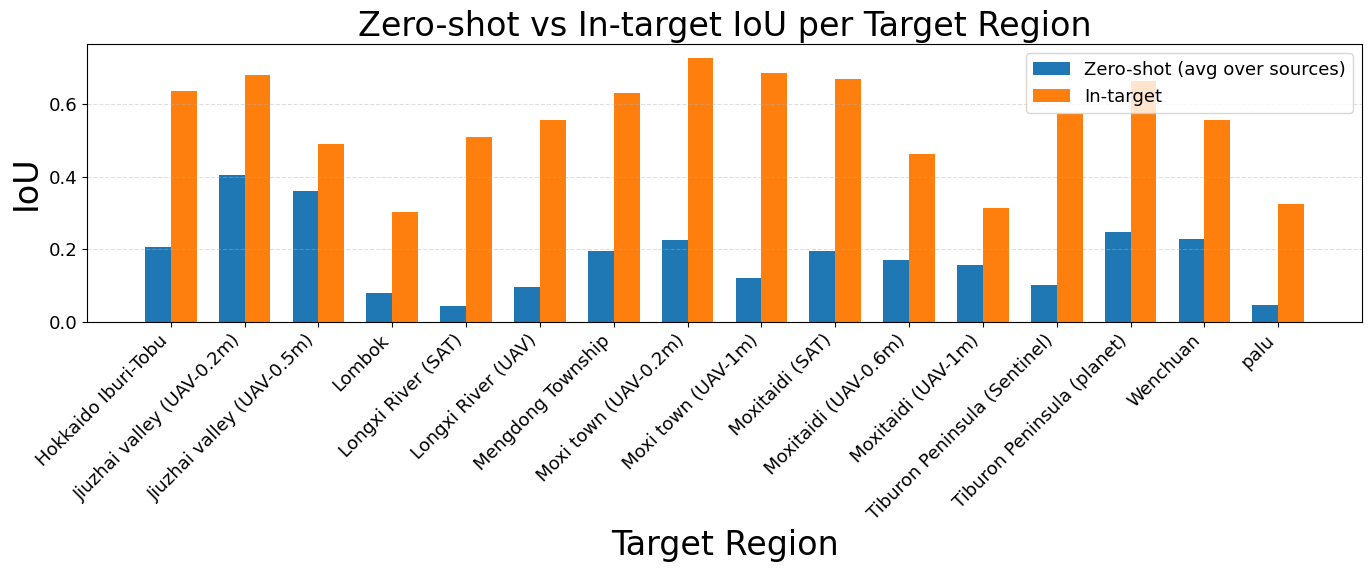

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ==== CONFIG: set your relative paths here ====
zero_shot_csv = "../../results/baseline/final_source_only_100_0.csv"
in_target_csv = "../../results/baseline/final_target_only.csv"

# ==== 1. Load CSVs ====
df_zero = pd.read_csv(zero_shot_csv)
df_target = pd.read_csv(in_target_csv)

df_zero["target_region"] = df_zero["target_region"].str.strip()
df_target["target_region"] = df_target["target_region"].str.strip()

# ==== 2. Compute mean zero-shot IoU ====
avg_zero_shot = (
    df_zero.groupby("target_region")["iou"]
    .mean()
    .reset_index()
    .rename(columns={"iou": "iou_zero_shot"})
)

# ==== 3. Extract in-target IoU ====
in_target_iou = (
    df_target[["target_region", "iou"]]
    .rename(columns={"iou": "iou_in_target"})
)

# ==== 4. Merge ====
merged = pd.merge(avg_zero_shot, in_target_iou, on="target_region", how="inner")
merged = merged.sort_values("target_region")
# print(merged)

# ==== 5. Plot ====

# Poster color theme
zero_shot_color = "#1f77b4"  # deep blue
in_target_color = "#ff7f0e"   # green

targets = merged["target_region"].tolist()
x = range(len(targets))
width = 0.35

plt.rcParams.update({
    "font.size": 16,        # bigger font for poster
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    [i - width/2 for i in x],
    merged["iou_zero_shot"],
    width,
    label="Zero-shot (avg over sources)",
    color=zero_shot_color
)

ax.bar(
    [i + width/2 for i in x],
    merged["iou_in_target"],
    width,
    label="In-target",
    color=in_target_color
)

ax.set_xlabel("Target Region")
ax.set_ylabel("IoU")
ax.set_title("Zero-shot vs In-target IoU per Target Region")
ax.set_xticks(list(x))
ax.set_xticklabels(targets, rotation=45, ha="right")

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Optional: save as PDF for poster
# plt.savefig("zero_shot_vs_in_target.pdf", dpi=300, bbox_inches="tight")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Colors matching your poster theme
zero_shot_color = "#2C4E72"   # deep blue from your title/header
in_target_color = "#4E7521"   # dark green from your intro header

plt.figure(figsize=(12, 6))
x = range(len(df_merged))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    df_merged["avg_zero_shot_iou"],
    width,
    label="Avg Zero-Shot",
    color=zero_shot_color
)

plt.bar(
    [i + width/2 for i in x],
    df_merged["in_target_iou"],
    width,
    label="In-Target",
    color=in_target_color
)

plt.xticks(x, df_merged["target_region"], rotation=45, ha="right")
plt.ylabel("IoU")
plt.title("Zero-shot vs In-target IoU per Target Region")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'df_merged' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
print("ZERO-SHOT COLUMNS:", df_zero.columns.tolist())
print("IN-TARGET COLUMNS:", df_target.columns.tolist())

ZERO-SHOT COLUMNS: ['source_region', 'target_region', 'precision', 'recall', 'f1', 'iou', 'miou', 'oa', 'bf1']
IN-TARGET COLUMNS: ['target_region', 'precision', 'recall', 'f1', 'iou', 'miou', 'oa', 'bf1']
